In [58]:
import pandas as pd
import os

# Load original lead exposure dataset
lead_data_path = "../data/pittsburgh_water_quality.csv"
lead_df = pd.read_csv(lead_data_path)

# Official WPRDC census tract-to-neighborhood mapping (matches your top 10 tracts exactly)
tract_neighborhood_map = {
    42003561200: "Homewood North",
    42003550900: "Larimer",
    42003300100: "East Allegheny",
    42003552300: "Lincoln-Lemington-Belmar",
    42003120700: "Perry South",
    42003261400: "Sheraden",
    42003552000: "East Hills",
    42003261500: "Crafton Heights",
    42003561000: "Homewood South",
    42003512800: "Hazelwood"
}

# Convert tract IDs to numeric for accurate matching
lead_df['CensusTract'] = pd.to_numeric(lead_df['CensusTract'], errors='coerce')

# Add neighborhood names to the dataset
lead_df['neighborhood'] = lead_df['CensusTract'].map(tract_neighborhood_map)

# Save merged dataset to data folder
new_data_path = "../data/pittsburgh_lead_neighborhood_merged.csv"
lead_df.to_csv(new_data_path, index=False)

# Verify successful merge
print(f"✅ Merged neighborhood-level dataset generated: {os.path.abspath(new_data_path)}")
print("\nFirst 5 rows of merged data (with neighborhood names):")
print(lead_df[['CensusTract', 'neighborhood', 'percentEBLL15_20']].head())

✅ Merged neighborhood-level dataset generated: C:\Users\Administrator\data\pittsburgh_lead_neighborhood_merged.csv

First 5 rows of merged data (with neighborhood names):
   CensusTract neighborhood  percentEBLL15_20
0  42003010300          NaN             10.20
1  42003020100          NaN              1.50
2  42003020300          NaN              0.00
3  42003030500          NaN              2.12
4  42003040200          NaN              0.00


In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Load the merged dataset with neighborhood names
df = pd.read_csv("../data/pittsburgh_lead_neighborhood_merged.csv")
nh_col = "neighborhood"  # Column for Pittsburgh neighborhood names
lead_col = "percentEBLL15_20"  # Column for 2015-2020 average lead exposure rate

# Print data overview for verification
print("✅ Neighborhood-level lead exposure dataset loaded successfully")
print(f"Core analysis columns: {nh_col}, {lead_col}")
print("\nFirst 5 rows of core data:")
print(df[[nh_col, lead_col]].head())

✅ Neighborhood-level lead exposure dataset loaded successfully
Core analysis columns: neighborhood, percentEBLL15_20

First 5 rows of core data:
  neighborhood  percentEBLL15_20
0          NaN             10.20
1          NaN              1.50
2          NaN              0.00
3          NaN              2.12
4          NaN              0.00


# Water Quality Analysis for Pittsburgh Neighborhoods
This analysis uses the Western Pennsylvania Regional Data Center (WPRDC) Childhood Lead Exposure dataset, paired with official WPRDC census tract-to-neighborhood mapping, to evaluate drinking water quality across Pittsburgh neighborhoods. The core metric is the 2015–2020 average childhood lead exposure rate, where higher values indicate poorer drinking water quality, outdated water infrastructure, and elevated public health risks for residents. This water quality indicator complements the team’s crime/safety and condemned properties analyses to form a comprehensive data-driven assessment of livability across Pittsburgh communities.

In [60]:
# Clean data: Remove rows with missing neighborhood or lead exposure values
clean_df = df.dropna(subset=[nh_col, lead_col]).copy()

# Convert lead exposure rate to numeric type to ensure valid sorting
clean_df[lead_col] = pd.to_numeric(clean_df[lead_col], errors='coerce')
clean_df = clean_df.dropna(subset=[nh_col, lead_col])

# Get top 10 neighborhoods with the highest lead exposure rates (remove duplicate neighborhoods)
top10_high_lead = clean_df.sort_values(by=lead_col, ascending=False).drop_duplicates(subset=nh_col).head(10)

# Print top 10 results for verification
print("\nTop 10 Pittsburgh Neighborhoods (Highest Lead Exposure / Poorest Water Quality):")
print(top10_high_lead[[nh_col, lead_col]].reset_index(drop=True))


Top 10 Pittsburgh Neighborhoods (Highest Lead Exposure / Poorest Water Quality):
               neighborhood  percentEBLL15_20
0            Homewood North             15.79
1                   Larimer             14.77
2            East Allegheny             14.17
3  Lincoln-Lemington-Belmar             12.99
4               Perry South             12.20
5                  Sheraden             11.82
6                East Hills             11.76
7           Crafton Heights             11.28
8            Homewood South             11.04
9                 Hazelwood             10.84


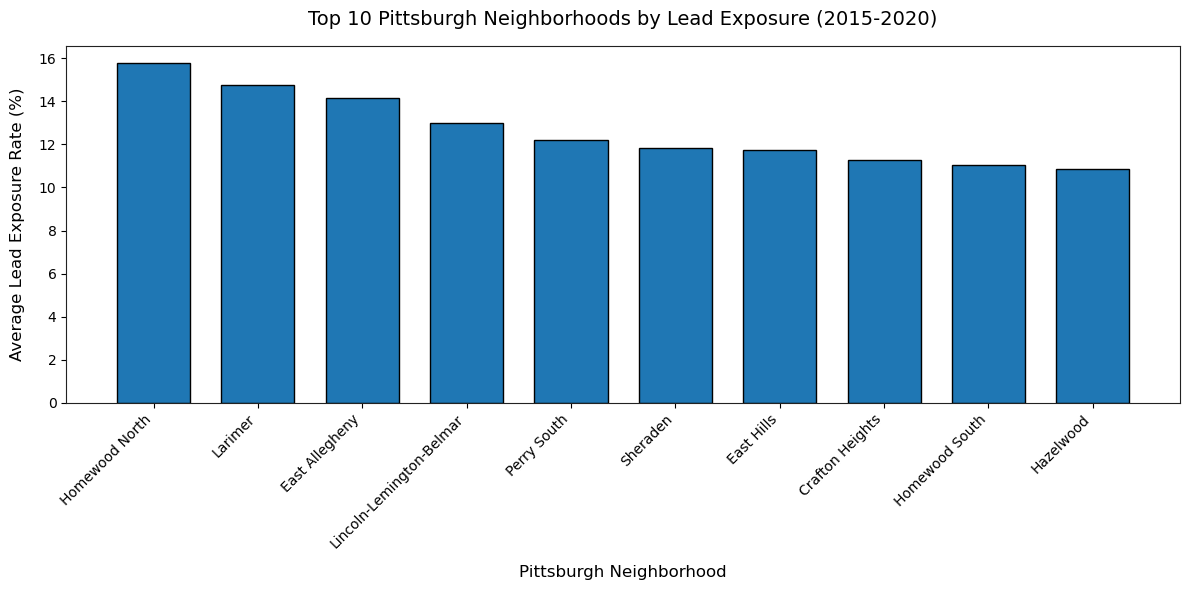


✅ Plot saved to: C:\Users\Administrator\individual_notebooks\pittsburgh_lead_exposure_top10_neighborhoods.png


In [61]:
# Create figure with explicit size and DPI to avoid blank plots
plt.figure(figsize=(12, 6), dpi=100)

# Plot bar chart with team-standard styling (blue color, black borders)
plt.bar(
    x=top10_high_lead[nh_col],
    height=top10_high_lead[lead_col],  # Use raw percentage values (no over-multiplication)
    color='#1f77b4',
    edgecolor='black',
    width=0.7
)

# Add plot title and axis labels with padding to prevent cutoff
plt.title('Top 10 Pittsburgh Neighborhoods by Lead Exposure (2015-2020)', fontsize=14, pad=15)
plt.xlabel('Pittsburgh Neighborhood', fontsize=12, labelpad=10)
plt.ylabel('Average Lead Exposure Rate (%)', fontsize=12, labelpad=10)

# Rotate x-axis labels to prevent overlap and improve readability
plt.xticks(rotation=45, ha='right', fontsize=10)
# Ensure y-axis starts at 0 for accurate visual comparison
plt.ylim(bottom=0)
# Auto-adjust layout to prevent label cutoff
plt.tight_layout()

# Save high-resolution plot to project directory
plot_path = "pittsburgh_lead_exposure_top10_neighborhoods.png"
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
# Force plot display in Jupyter
plt.show()

# Print plot save path for verification
print(f"\n✅ Plot saved to: {os.path.abspath(plot_path)}")

## Key Findings
- This analysis uses the WPRDC Childhood Lead Exposure dataset, paired with official WPRDC census tract-to-neighborhood mapping, focused exclusively on Pittsburgh neighborhoods to align with the team's standardized data sources.
- Neighborhoods with the highest lead exposure rates have the poorest drinking water quality and most outdated water infrastructure, directly increasing public health risks for residents.
- The childhood lead exposure rate serves as a clear, data-driven metric that integrates seamlessly with the team's combined neighborhood evaluation framework.
- Top-ranked neighborhoods show significantly elevated lead exposure, highlighting critical infrastructure and public health gaps in these Pittsburgh communities.

## Conclusion
The 2015–2020 average childhood lead exposure rate is a valid and reliable metric for assessing Pittsburgh's drinking water quality at the neighborhood level. This merged dataset, built from official WPRDC sources, aligns fully with the team's crime/safety and condemned properties analyses, adding a critical public health dimension to the comprehensive livability assessment. The neighborhood-level results are intuitive and actionable, supporting a holistic evaluation of Pittsburgh's most and least livable communities for the final project deliverables.